# Semana 1: Complejidad — ¿Por qué los sistemas nos sorprenden?

**MISE Systems Analytics** | Universidad de los Andes

> *"Un sistema complejo es aquel donde el todo es distinto a la suma de las partes."*
> — Herbert Simon

## Objetivos de aprendizaje
1. Identificar propiedades emergentes, retroalimentación y no-linealidad
2. Distinguir distribuciones gaussianas de distribuciones de cola pesada (*fat tails*)
3. Reconocer *tipping points*, *lock-in* y dependencia de camino
4. Construir Diagramas de Lazo Causal (CLD) básicos

| Nivel | Símbolo | Contenido |
|-------|---------|----------|
| Intuición | **Nivel 1 —** | Simulaciones interactivas de conceptos fundamentales |
| Energía | **Nivel 2 —** | Aplicaciones al sector eléctrico colombiano |
| Profesional | **Nivel 3 —** | Lecturas y conexiones con la frontera del conocimiento |

In [1]:
import sys
sys.path.insert(0, '.')
from mise_utils import viz, complexity, energy_data
from mise_utils.viz import COLORS, apply_mise_style
import numpy as np
import matplotlib.pyplot as plt
apply_mise_style()
print("Módulos cargados correctamente")

Módulos cargados correctamente


---
# **Nivel 1 —** Nivel 1: Intuición — Conceptos fundamentales

## 1.1 Emergencia: el juego del tráfico

Imagina una autopista circular con autos que siguen reglas simples:
- **Acelerar** hasta la velocidad máxima
- **Frenar** si el auto de adelante está cerca
- **Frenado aleatorio** (distracción, imprudencia)

¿Qué pasa cuando aumentamos la densidad de autos?

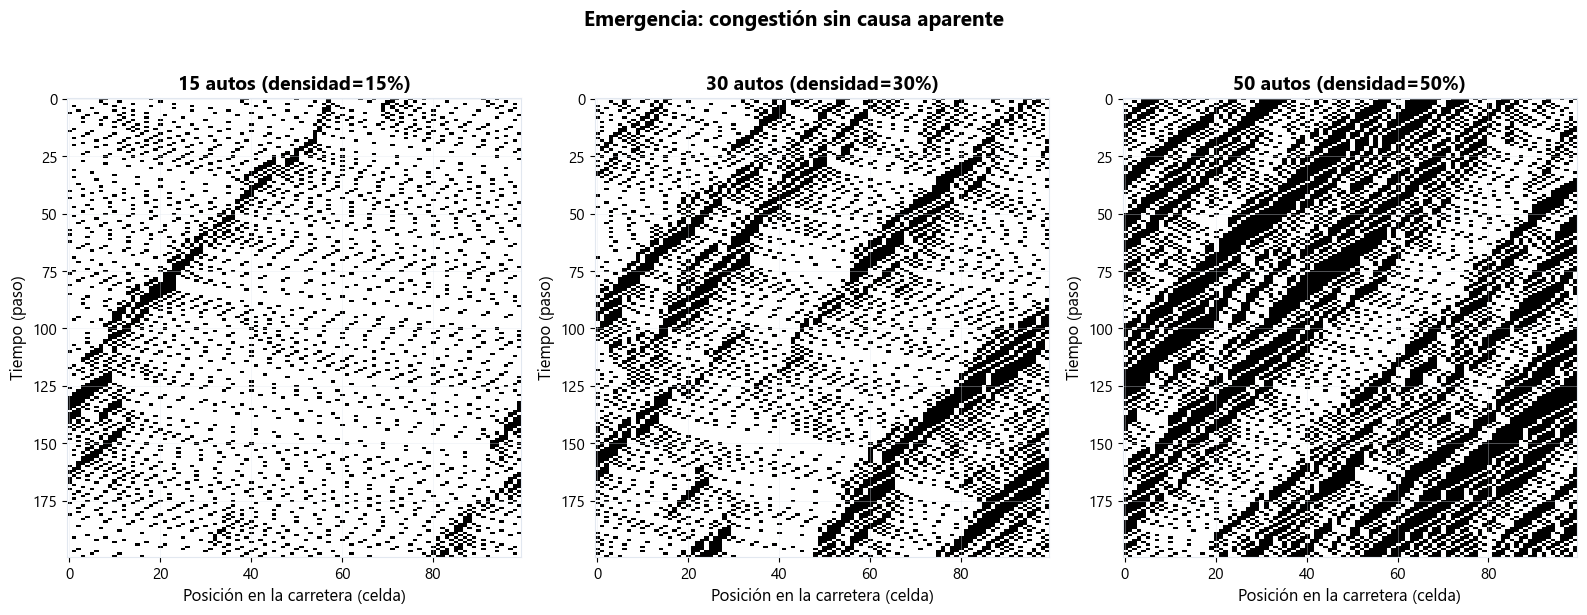

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, n_autos in enumerate([15, 30, 50]):
    resultado = complexity.simular_trafico(n_autos=n_autos, n_celdas=100)
    complexity.plot_diagrama_espacio_tiempo(resultado, ax=axes[i])
    axes[i].set_title(f"{n_autos} autos (densidad={resultado['densidad']:.0%})")

plt.suptitle("Emergencia: congestión sin causa aparente",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Insight:** **Insight**: Con pocos autos (15%), el tráfico fluye libre. Con densidad media (30%), aparecen **atascos fantasma** — ondas de congestión que viajan *hacia atrás*. Nadie frenó primero; el atasco **emerge** de las interacciones locales. Esto es **emergencia** (*emergence*).

## 1.2 Retroalimentación: bola de nieve vs termostato

Dos tipos fundamentales de *feedback*:
- **Refuerzo (R)**: más → más (crecimiento exponencial) 
- **Balance (B)**: desviación → corrección (búsqueda de meta) **Nivel 3 —**

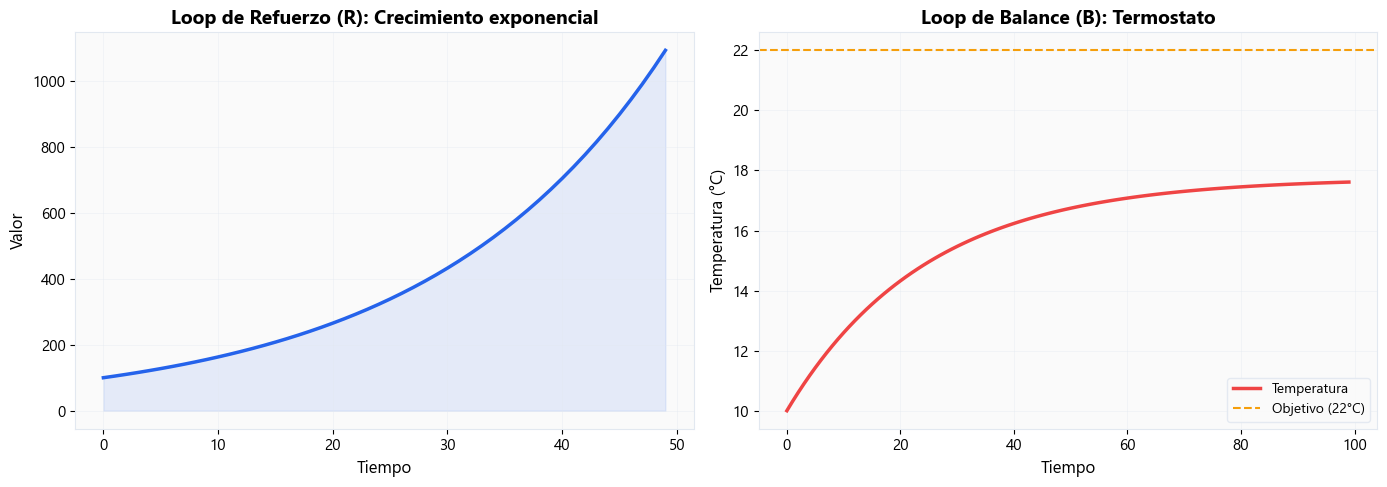

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loop de refuerzo
resultado_r = complexity.simular_feedback_refuerzo(tasa_crecimiento=0.05)
axes[0].plot(resultado_r['t'], resultado_r['valor'],
             color=COLORS['primary'], linewidth=2.5)
axes[0].set_title('Loop de Refuerzo (R): Crecimiento exponencial')
axes[0].set_xlabel('Tiempo'); axes[0].set_ylabel('Valor')
axes[0].fill_between(resultado_r['t'], resultado_r['valor'],
                     alpha=0.1, color=COLORS['primary'])

# Loop de balance
resultado_b = complexity.simular_termostato(temp_objetivo=22, temp_inicial=10)
axes[1].plot(resultado_b['t'], resultado_b['temperatura'],
             color=COLORS['danger'], linewidth=2.5, label='Temperatura')
axes[1].axhline(y=22, color=COLORS['accent'], linestyle='--',
                linewidth=1.5, label='Objetivo (22°C)')
axes[1].set_title('Loop de Balance (B): Termostato')
axes[1].set_xlabel('Tiempo'); axes[1].set_ylabel('Temperatura (°C)')
axes[1].legend()

plt.tight_layout(); plt.show()

**Insight:** **Insight**: Los loops de **refuerzo** producen crecimiento (o colapso) exponencial — la "bola de nieve". Los loops de **balance** buscan una meta, como un termostato. Todo sistema complejo es una combinación de ambos tipos.

## 1.3 Cisnes negros: ¿sus datos son gaussianos?

La distribución Gaussiana (*normal*) asume que los eventos extremos son prácticamente imposibles. Pero en sistemas complejos, las distribuciones de **cola pesada** (*fat tails*) hacen que los "cisnes negros" sean mucho más frecuentes.

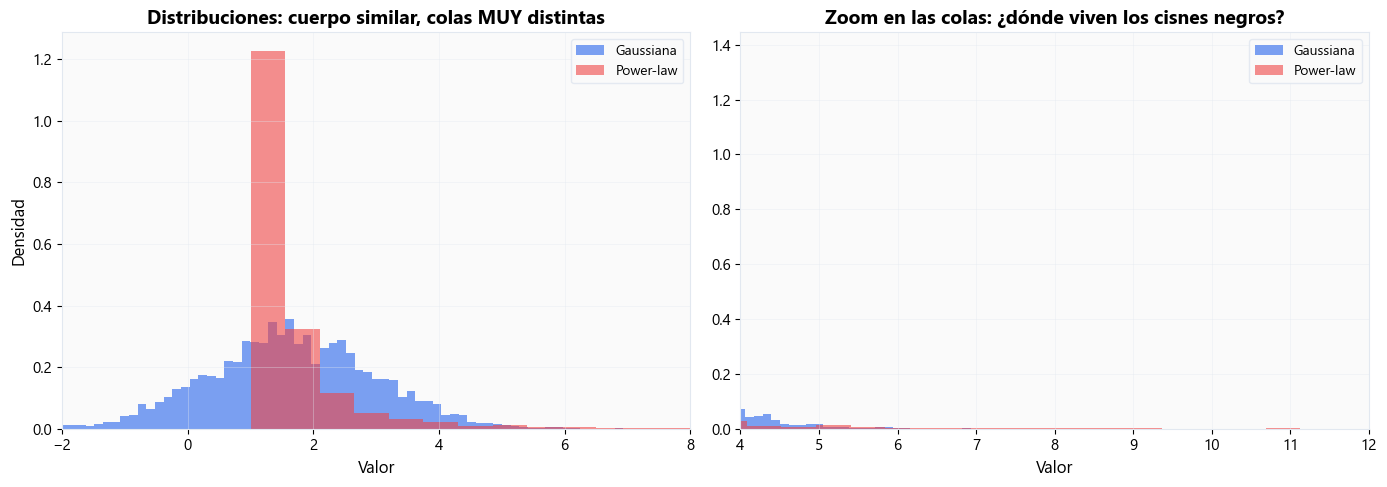

In [4]:
muestras = complexity.generar_muestras_comparacion(n=5000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(muestras['gaussiana'], bins=80, density=True,
             alpha=0.6, color=COLORS['primary'], label='Gaussiana')
axes[0].hist(muestras['power_law'], bins=80, density=True,
             alpha=0.6, color=COLORS['danger'], label='Power-law')
axes[0].set_xlim(-2, 8)
axes[0].set_title('Distribuciones: cuerpo similar, colas MUY distintas')
axes[0].legend(); axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Densidad')

axes[1].hist(muestras['gaussiana'], bins=100, density=True,
             alpha=0.6, color=COLORS['primary'], label='Gaussiana')
axes[1].hist(muestras['power_law'], bins=100, density=True,
             alpha=0.6, color=COLORS['danger'], label='Power-law')
axes[1].set_xlim(4, 12)
axes[1].set_title('Zoom en las colas: ¿dónde viven los cisnes negros?')
axes[1].legend(); axes[1].set_xlabel('Valor')

plt.tight_layout(); plt.show()

In [5]:
tabla = complexity.tabla_probabilidades_extremas()
print("Probabilidad de eventos extremos: Gaussiana vs Power-law\n")
print(tabla.to_string(index=False))

Probabilidad de eventos extremos: Gaussiana vs Power-law

 σ P(Gaussiana) P(Power-law) Ratio (PL/G)
3σ     1.35e-03     1.07e-02           8×
4σ     3.17e-05     6.22e-03         196×
5σ     2.87e-07     3.98e-03       13888×
6σ     9.87e-10     2.73e-03     2763630×


**Insight:** **Insight**: Un evento de 6σ bajo la Gaussiana ocurre ~1 vez cada mil millones. Bajo una distribución de cola pesada, ocurre **miles de veces más frecuentemente**. Si modelamos el mundo real con campanas de Gauss cuando los datos tienen colas pesadas, **subestimamos enormemente los riesgos**.

## 1.4 Lock-in: ¿por qué todos usamos QWERTY?

**Dependencia de camino** (*path dependency*): pequeñas ventajas iniciales pueden amplificarse hasta dominar el mercado — aunque la alternativa sea objetivamente mejor.

Compare dos escenarios:
- **Con rendimientos crecientes**: el que gana un poco, gana más
- **Nivel 2 —** **Sin rendimientos crecientes**: cada agente elige al azar

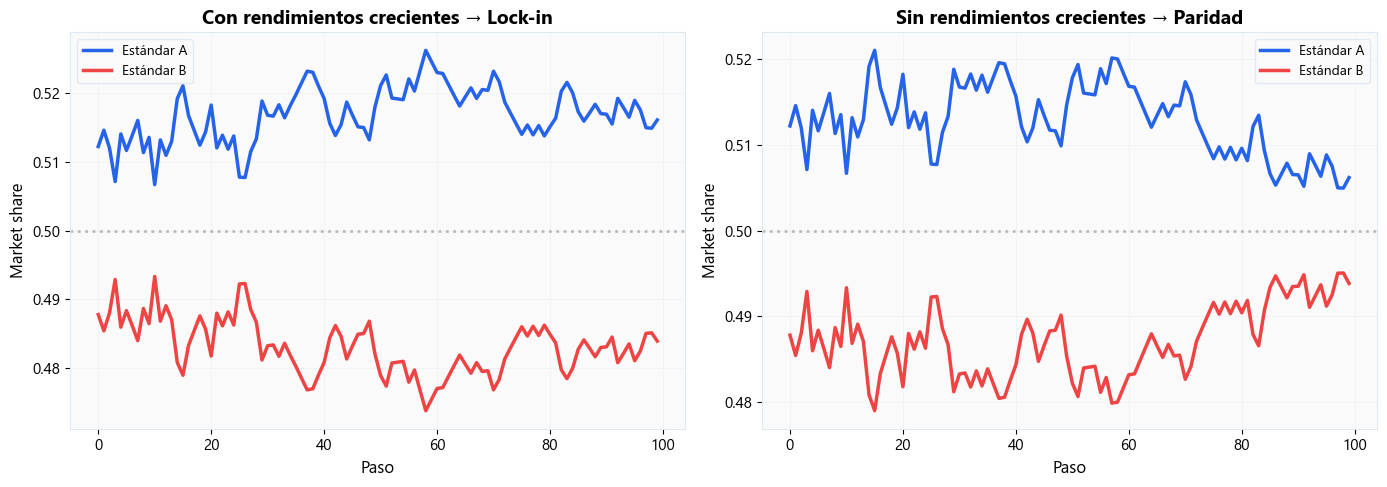

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con rendimientos crecientes
resultado_ir = complexity.simular_lockin(rendimientos_crecientes=True, seed=42)
axes[0].plot(resultado_ir['t'], resultado_ir['share_A'],
             color=COLORS['primary'], linewidth=2.5, label='Estándar A')
axes[0].plot(resultado_ir['t'], resultado_ir['share_B'],
             color=COLORS['danger'], linewidth=2.5, label='Estándar B')
axes[0].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title('Con rendimientos crecientes → Lock-in')
axes[0].set_xlabel('Paso'); axes[0].set_ylabel('Market share'); axes[0].legend()

# Sin rendimientos crecientes
resultado_sin = complexity.simular_lockin(rendimientos_crecientes=False, seed=42)
axes[1].plot(resultado_sin['t'], resultado_sin['share_A'],
             color=COLORS['primary'], linewidth=2.5, label='Estándar A')
axes[1].plot(resultado_sin['t'], resultado_sin['share_B'],
             color=COLORS['danger'], linewidth=2.5, label='Estándar B')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Sin rendimientos crecientes → Paridad')
axes[1].set_xlabel('Paso'); axes[1].set_ylabel('Market share'); axes[1].legend()

plt.tight_layout(); plt.show()

**Insight:** **Insight**: Con **rendimientos crecientes** (*increasing returns*), una ventaja inicial mínima se amplifica hasta el dominio total — *lock-in*. Ejemplos: QWERTY, VHS vs Betamax, Windows vs alternativas. En energía: ¿por qué es tan difícil abandonar los combustibles fósiles? La infraestructura existente genera su propia inercia.

## 1.5 Tipping points: la bola en la colina

Un **punto de inflexión** (*tipping point*) es un umbral más allá del cual el sistema cambia abruptamente de estado. Visualicemos esto con un **paisaje de energía potencial**.

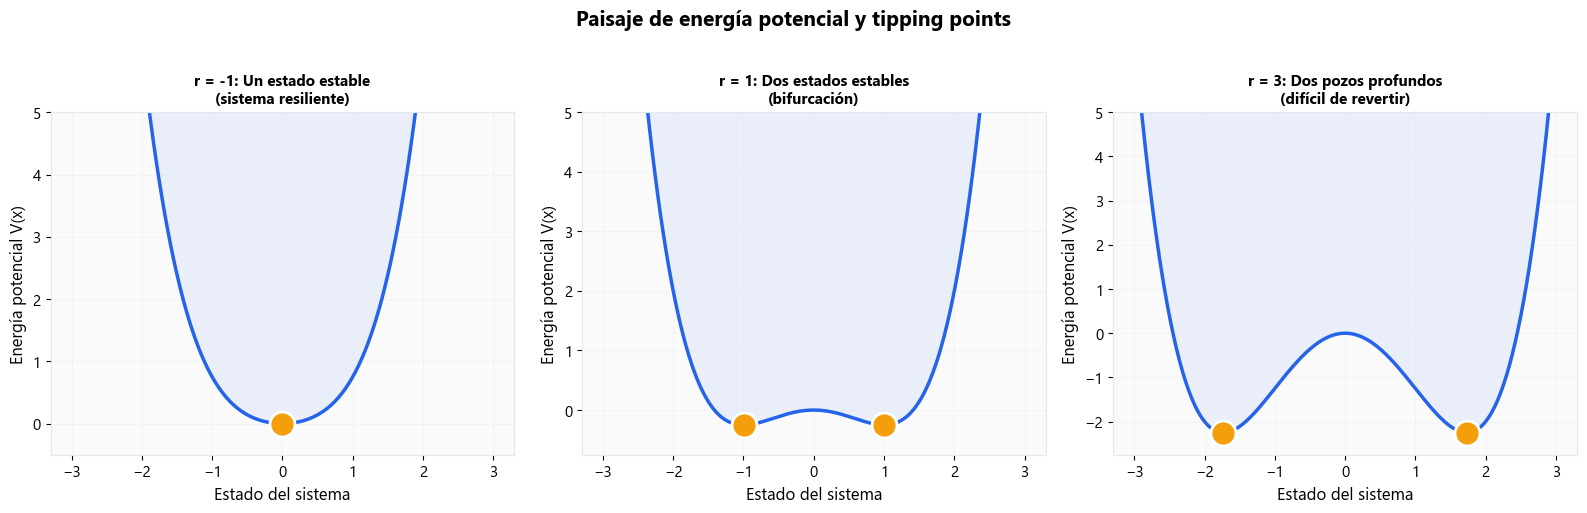

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, r in enumerate([-1.0, 1.0, 3.0]):
    complexity.plot_tipping_point(r, ax=axes[i])

axes[0].set_title('r = -1: Un estado estable\n(sistema resiliente)', fontsize=11)
axes[1].set_title('r = 1: Dos estados estables\n(bifurcación)', fontsize=11)
axes[2].set_title('r = 3: Dos pozos profundos\n(difícil de revertir)', fontsize=11)

plt.suptitle('Paisaje de energía potencial y tipping points',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Insight:** **Insight**: Cuando un sistema tiene **dos pozos** (estados estables), se necesita un empujón suficientemente grande para saltar de uno al otro. Pero cerca del *tipping point*, un cambio pequeño puede causar un salto irreversible. Ejemplos: colapso de ecosistemas, crisis financieras, transiciones energéticas.

---
# **Nivel 2 —** Nivel 2: Energía — Aplicaciones al sector eléctrico colombiano

## 2.1 El ciclo precio-inversión-capacidad

El sector eléctrico colombiano exhibe un ciclo clásico de retroalimentación con retardos:

**Precio alto** → inversión en nuevas plantas → exceso de capacidad → **precio bajo** → no se invierte → escasez → **precio alto** → ...

Este ciclo tiene un **retardo de construcción** (~5 años), lo que genera oscilaciones.

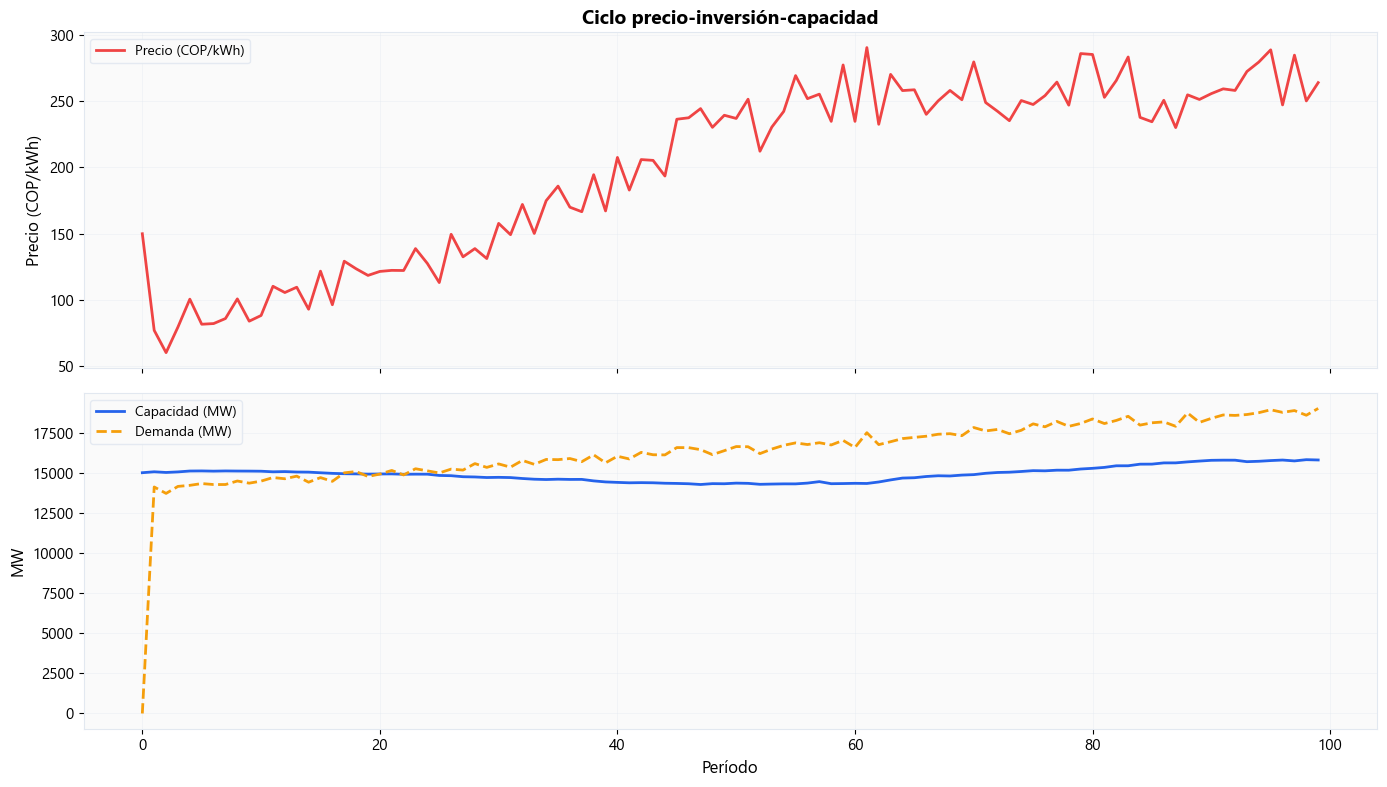

In [8]:
ciclo = energy_data.generar_ciclo_inversion_capacidad()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ciclo['t'], ciclo['precio'], color=COLORS['danger'],
             linewidth=2, label='Precio (COP/kWh)')
axes[0].set_ylabel('Precio (COP/kWh)'); axes[0].legend()
axes[0].set_title('Ciclo precio-inversión-capacidad')

axes[1].plot(ciclo['t'], ciclo['capacidad'], color=COLORS['primary'],
             linewidth=2, label='Capacidad (MW)')
axes[1].plot(ciclo['t'], ciclo['demanda'], color=COLORS['accent'],
             linewidth=2, linestyle='--', label='Demanda (MW)')
axes[1].set_ylabel('MW'); axes[1].set_xlabel('Período'); axes[1].legend()

plt.tight_layout(); plt.show()

**Insight:** **Insight**: El retardo entre la señal de precio y la entrada de nueva capacidad genera **oscilaciones endógenas** — un patrón clásico de dinámica de sistemas. La CREG intenta suavizar esto con mecanismos como el **Cargo por Confiabilidad** (CxC).

## 2.2 ¿Son gaussianos los precios de bolsa?

Los precios del mercado eléctrico colombiano, especialmente durante **El Niño**, exhiben distribuciones de cola pesada. Comprobemos.

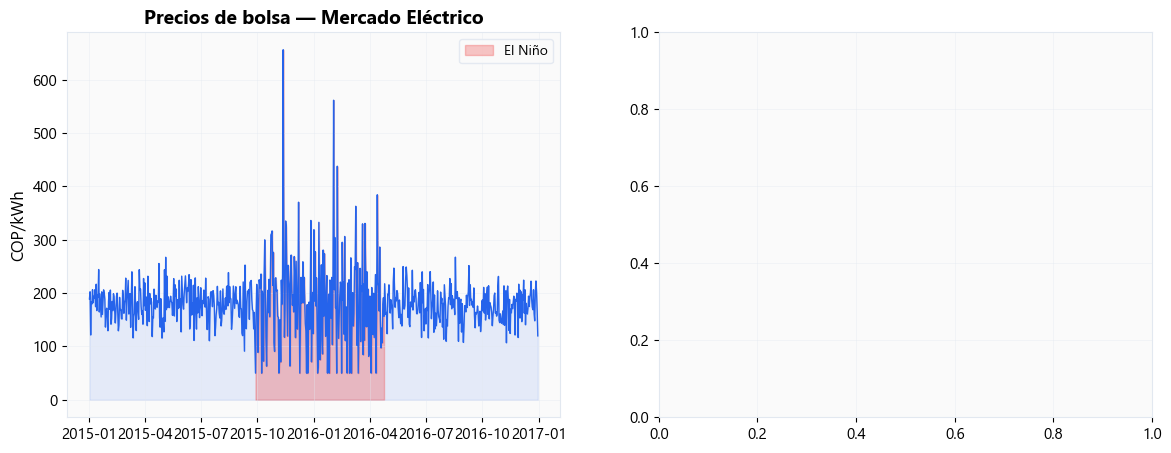

In [9]:
from scipy import stats

precios = energy_data.generar_precios_bolsa()
retornos = precios['precio_bolsa'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Serie temporal
axes[0].plot(precios['fecha'], precios['precio_bolsa'],
             color=COLORS['primary'], linewidth=1)
axes[0].fill_between(precios['fecha'], precios['precio_bolsa'],
                     alpha=0.1, color=COLORS['primary'])
mask_nino = precios['es_nino']
axes[0].fill_between(precios['fecha'][mask_nino],
                     precios['precio_bolsa'][mask_nino],
                     alpha=0.3, color=COLORS['danger'], label='El Niño')
axes[0].set_title('Precios de bolsa — Mercado Eléctrico')
axes[0].set_ylabel('COP/kWh'); axes[0].legend()

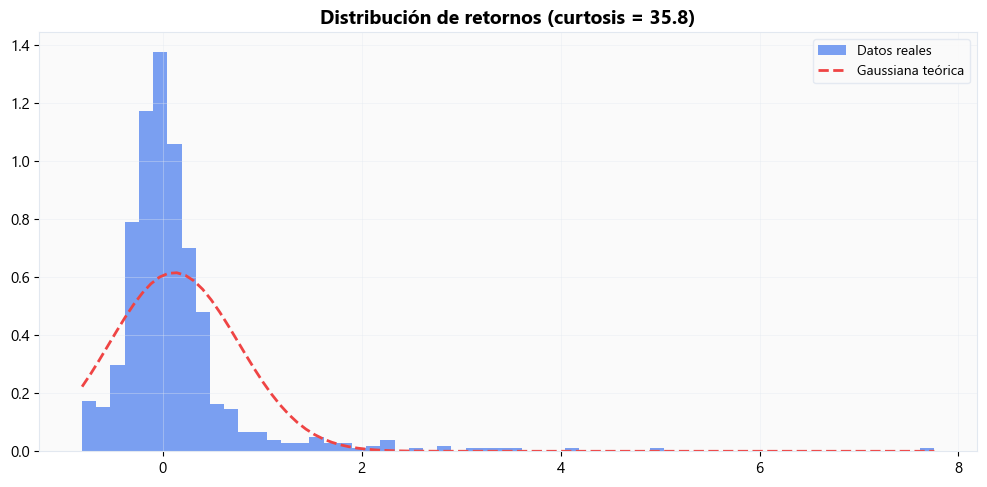

Curtosis: 35.8 (Gaussiana = 0).
¿Cola pesada? SÍ 


In [10]:
# Histograma + test de normalidad
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(retornos, bins=60, density=True, alpha=0.6,
        color=COLORS['primary'], label='Datos reales')
x_range = np.linspace(retornos.min(), retornos.max(), 100)
ax.plot(x_range, stats.norm.pdf(x_range, retornos.mean(), retornos.std()),
        color=COLORS['danger'], linewidth=2, linestyle='--',
        label='Gaussiana teórica')
ax.set_title(f'Distribución de retornos (curtosis = {stats.kurtosis(retornos):.1f})')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Curtosis: {stats.kurtosis(retornos):.1f} (Gaussiana = 0).")
print(f"¿Cola pesada? {'SÍ ' if stats.kurtosis(retornos) > 3 else 'NO '}")

**Insight:** **Insight**: La curtosis alta confirma **colas pesadas**. Los precios de bolsa en Colombia NO son gaussianos — los eventos extremos (crisis de El Niño) son mucho más frecuentes de lo que predice una distribución normal. Los modelos de riesgo que asumen normalidad **subestiman el riesgo real**.

## 2.3 CLD interactivo: la crisis de El Niño 2015-2016

Construyamos paso a paso un **Diagrama de Lazo Causal** (CLD) de la crisis de El Niño que afectó al sector eléctrico colombiano.

La sequía redujo los embalses → menos generación hidro → más generación térmica (costosa) → precios se dispararon → racionamiento parcial.

C:\Users\ch.gomez171\AppData\Local\Temp\ipykernel_20372\3510976403.py:8: UserWarning: Glyph 8635 (\N{CLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\ch.gomez171\AppData\Local\Temp\ipykernel_20372\3510976403.py:8: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8635 (\N{CLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


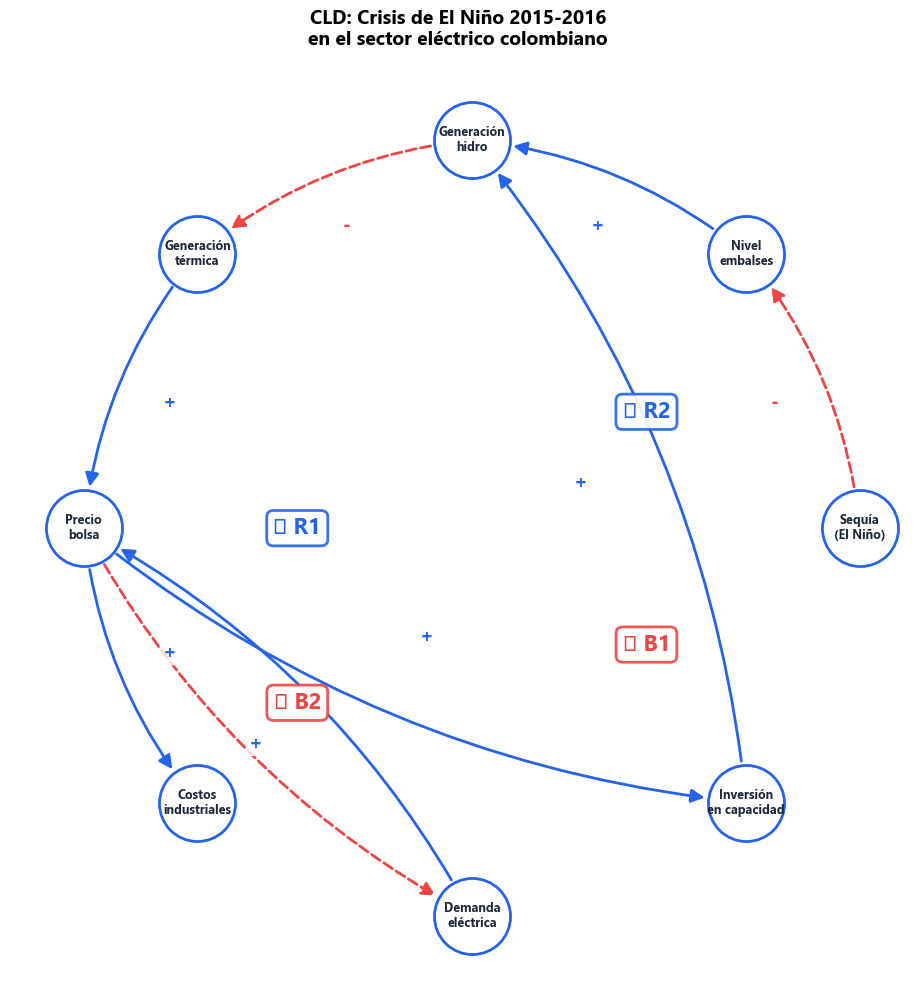

In [11]:
variables, flechas, lazos = complexity.cld_el_nino()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
complexity.dibujar_cld(
    variables, flechas, lazos,
    titulo='CLD: Crisis de El Niño 2015-2016\nen el sector eléctrico colombiano',
    ax=ax)
plt.tight_layout(); plt.show()

**Insight:** **Insight**: El CLD revela que la crisis de El Niño no fue un evento simple sino un **sistema de lazos interconectados**:
- **R1** (Espiral de costos): sequía → menos hidro → más térmicas → precio sube
- **B1** (Respuesta demanda): precio alto → consumidores reducen demanda
- **R2** (Ciclo inversión): precio alto → más inversión → más capacidad futura
- **B2** (Feedback demanda-precio): menos demanda → precio baja

La política del sector busca **fortalecer los lazos de balance** y **debilitar los de refuerzo** destructivos.

## 2.4 Embalses vs precio: la no-linealidad

La relación entre el nivel de embalses y el precio NO es lineal. Cuando los embalses caen por debajo del ~40%, el precio sube **exponencialmente**.

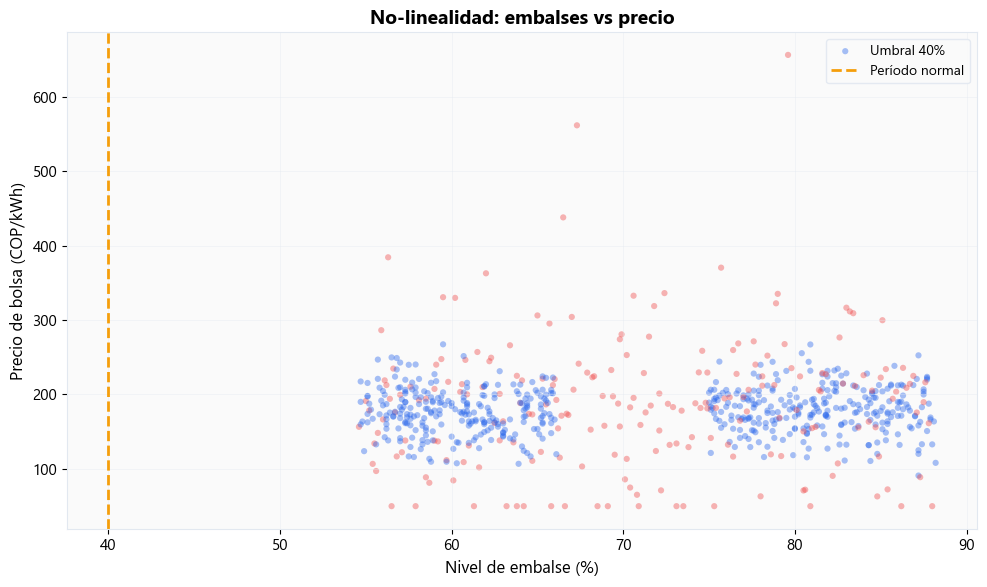

In [12]:
precios = energy_data.generar_precios_bolsa()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors_scatter = [COLORS['danger'] if x else COLORS['primary']
                  for x in precios['es_nino']]
ax.scatter(precios['nivel_embalse'], precios['precio_bolsa'],
           c=colors_scatter, alpha=0.4, s=20, edgecolors='none')
ax.axvline(x=40, color=COLORS['accent'], linestyle='--',
           linewidth=2, label='Umbral ~40%')
ax.set_xlabel('Nivel de embalse (%)')
ax.set_ylabel('Precio de bolsa (COP/kWh)')
ax.set_title('No-linealidad: embalses vs precio',
             fontsize=14, fontweight='bold')
ax.legend(['Umbral 40%', 'Período normal', 'El Niño'])

plt.tight_layout(); plt.show()

**Insight:** **Insight**: Por encima del 40% de embalse, el precio se mantiene estable (~180 COP/kWh). Por debajo, sube **exponencialmente**. Esta **no-linealidad** es una característica fundamental de los sistemas complejos: los mismos inputs pueden producir outputs dramáticamente diferentes dependiendo del estado del sistema.

---
# **Nivel 3 —** Nivel 3: Profesional — Conexiones con la frontera

> *Esta sección no tiene código — es lectura para profundizar.*

## 3.1 Sensitive Intervention Points (SIPs)

Farmer et al. (2019) proponen que la transición energética tiene **puntos de intervención sensibles** — lugares donde una acción relativamente pequeña puede desencadenar cambios transformadores en todo el sistema.

Ejemplos de SIPs en energía:
- **Subsidios focalizados** a tecnologías en el "punto de inflexión" de su curva de costos
- **Estándares regulatorios** que crean masa crítica de adopción
- **Infraestructura de red** que habilita nuevas configuraciones del mercado

 **Lectura**: Farmer, J.D. et al. (2019). "Sensitive intervention points in the post-carbon transition." *Science*, 364(6436), 132-134.

## 3.2 Modelado de riesgo con colas pesadas

La **Teoría de Valores Extremos** (EVT — *Extreme Value Theory*) ofrece herramientas rigurosas para modelar las colas de las distribuciones sin asumir normalidad.

Conceptos clave:
- **Distribución de Pareto Generalizada** (GPD): modela los excesos sobre un umbral
- **Value at Risk** (VaR) y **Expected Shortfall** (ES): métricas de riesgo que deben calcularse con GPD, no con Gaussiana
- **Índice de cola** (*tail index*): cuantifica qué tan pesada es la cola

En el sector energético colombiano, EVT es esencial para:
- Dimensionar el **Cargo por Confiabilidad** (CxC)
- Evaluar riesgos de contratos bilaterales
- Planificar la capacidad de respaldo ante eventos extremos

 **Lectura**: McNeil, A.J. et al. (2015). *Quantitative Risk Management*. Princeton University Press. Capítulos 4-5.

---
#  Cierre: ¿Qué aprendimos?

| Concepto | Ejemplo energético | Herramienta |
|----------|-------------------|-------------|
| Emergencia | Congestión en redes de transmisión | Autómatas celulares |
| Retroalimentación | Ciclo precio-inversión | Diagramas de lazo causal (CLD) |
| Colas pesadas | Precios de bolsa durante El Niño | Estadística de valores extremos |
| Lock-in | Dependencia de combustibles fósiles | Modelos de rendimientos crecientes |
| Tipping points | Colapso de embalses < 40% | Paisajes de energía potencial |

##  Preview Semana 2: Redes

La próxima semana pasamos de los conceptos de complejidad a las **redes**: ¿cómo está conectado el Sistema Interconectado Nacional? ¿Qué pasa si falla una subestación crítica? ¿Cómo se propagan las cascadas de fallas?

*Preparen sus grafos — la red eléctrica colombiana les espera.* 